In [14]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime

In [15]:
df = pd.read_csv("pendulum_trajectories.csv")

In [16]:
df["theta"] = (df["theta"] + np.pi) % (2 * np.pi) - np.pi
df["theta_next"] = (df["theta_next"] + np.pi) % (2 * np.pi) - np.pi

In [17]:
train = df[df["split"] == "train"]

In [18]:
class SimDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx, :]
    
dataset = SimDataset(train[["theta", "omega"]].values, train[["theta_next", "omega_next"]].values)

loader = DataLoader(dataset, batch_size=32)

In [19]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.mlp(x)

In [20]:
def loss_fn(y, y_hat):
    return nn.functional.mse_loss(y_hat, y)

In [21]:
hidden_dim = 16
model = MLP(2, hidden_dim, 2)

lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [22]:
epochs = 30

for epoch in range(epochs):
    total_loss = 0
    for x, y in loader:
        optimizer.zero_grad()
        
        x = x.to(torch.float32)
        y = y.to(torch.float32)
        
        y_hat = model(x)
        
        loss = loss_fn(y, y_hat)
        total_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    print(f"Epoch: {epoch+1} | Loss: {total_loss / len(loader)}")
    

Epoch: 1 | Loss: 3.04731404950538
Epoch: 2 | Loss: 0.5882784967937792
Epoch: 3 | Loss: 0.3761599678509086
Epoch: 4 | Loss: 0.2750632754653188
Epoch: 5 | Loss: 0.19924898406832045
Epoch: 6 | Loss: 0.14622023163931036
Epoch: 7 | Loss: 0.11013119089866123
Epoch: 8 | Loss: 0.08522384102777225
Epoch: 9 | Loss: 0.06756190546608319
Epoch: 10 | Loss: 0.05478147235425353
Epoch: 11 | Loss: 0.04547048270038192
Epoch: 12 | Loss: 0.038723408889704464
Epoch: 13 | Loss: 0.03389150647291602
Epoch: 14 | Loss: 0.03046711119497334
Epoch: 15 | Loss: 0.028042498759046918
Epoch: 16 | Loss: 0.02629981321287091
Epoch: 17 | Loss: 0.025007595977687046
Epoch: 18 | Loss: 0.024012341636091106
Epoch: 19 | Loss: 0.023223318119229102
Epoch: 20 | Loss: 0.022593092031587207
Epoch: 21 | Loss: 0.022097845827128444
Epoch: 22 | Loss: 0.021721791711914636
Epoch: 23 | Loss: 0.02144855212905946
Epoch: 24 | Loss: 0.021259365055253925
Epoch: 25 | Loss: 0.021136020597058165
Epoch: 26 | Loss: 0.021063937302798253
Epoch: 27 | Loss

In [23]:
model.eval()
test = df[df["split"] == "test"]

x_test = torch.tensor(test[["theta", "omega"]].values, dtype=torch.float32)
y_test = torch.tensor(test[["theta_next", "omega_next"]].values, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(x_test)
    test_loss = nn.functional.mse_loss(y_pred, y_test)

print(f"Test MSE: {test_loss.item():.6f}")

# Per-component breakdown so you can see if theta or omega is harder to predict
theta_mse = nn.functional.mse_loss(y_pred[:, 0], y_test[:, 0])
omega_mse = nn.functional.mse_loss(y_pred[:, 1], y_test[:, 1])
print(f"Theta MSE: {theta_mse.item():.6f} | Omega MSE: {omega_mse.item():.6f}")

Test MSE: 0.001513
Theta MSE: 0.000583 | Omega MSE: 0.002444


In [24]:
theta0 = 1.0  # radians
omega0 = 0.0  # rad/s
n_steps = 1000

rows = []
state = torch.tensor([[theta0, omega0]], dtype=torch.float32)

model.eval()
with torch.no_grad():
    for _ in range(n_steps):
        next_state = model(state)

        theta_next = (next_state[0, 0].item() + np.pi) % (2 * np.pi) - np.pi
        omega_next = next_state[0, 1].item()

        rows.append([theta_next, omega_next])
        state = torch.tensor([[theta_next, omega_next]], dtype=torch.float32)

arr = np.array(rows)  # shape (N, 2) — [theta, omega] per row
np.save("mlp_trajectory.npy", arr)
print(f"Saved {len(arr)} steps to mlp_trajectory.npy")

Saved 1000 steps to mlp_trajectory.npy


In [25]:
now = datetime.now()
date_time = now.strftime("%m-%d-%H:%M:%S")

torch.save(model.state_dict(), f"mlp_models/mlp-{date_time}-{hidden_dim}hdim.pth")

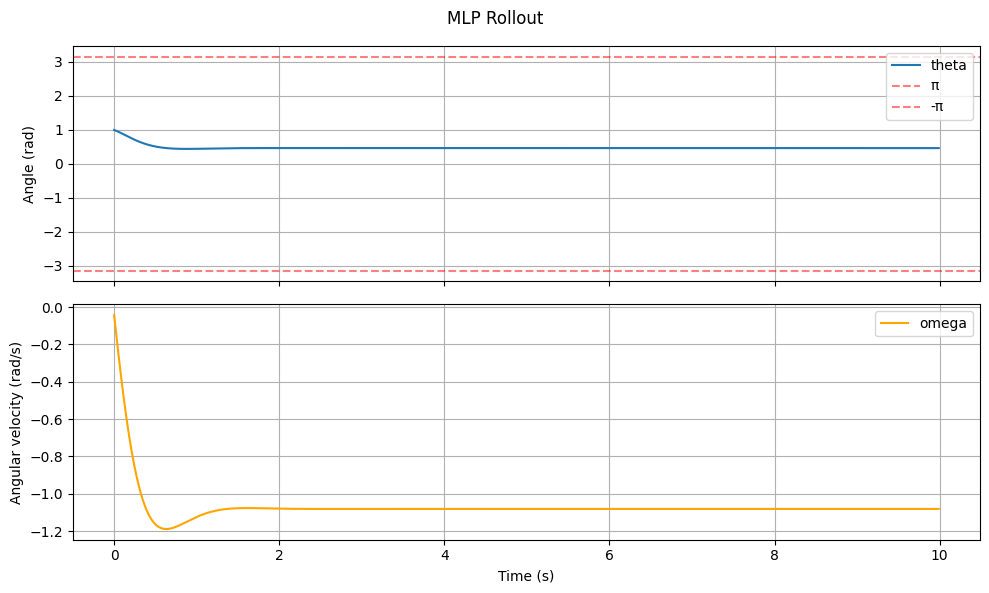

In [26]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.load("mlp_trajectory.npy")
t = np.arange(len(arr)) * 0.01

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t, arr[:, 0], label="theta")
ax1.set_ylabel("Angle (rad)")
ax1.axhline(np.pi, color="r", linestyle="--", alpha=0.5, label="π")
ax1.axhline(-np.pi, color="r", linestyle="--", alpha=0.5, label="-π")
ax1.legend()
ax1.grid(True)

ax2.plot(t, arr[:, 1], label="omega", color="orange")
ax2.set_ylabel("Angular velocity (rad/s)")
ax2.set_xlabel("Time (s)")
ax2.legend()
ax2.grid(True)

plt.suptitle("MLP Rollout")
plt.tight_layout()
plt.show()